In [49]:
from importlib import reload
import sys
from pathlib import Path

src_path = (Path.cwd().parent ).resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
print("src_path:", src_path)

import src.dictionary_match
import src.embedder
import src.score
import src.title_similarity
import src.skills_extraction
import src.skills
import src.preprocessing
import app
dictionary_match = reload(src.dictionary_match)
embedder = reload(src.embedder)
score = reload(src.score)
title_similarity = reload(src.title_similarity)
skill_extraction = reload(src.skills_extraction)
skill = reload(src.skills)
preprocessing = reload(src.preprocessing)
from src.dictionary_match import compute_dictionary_pairs_and_topk, dumps_skill_columns
from src.dictionary_match import to_skill_list
from app import parse_pdf
from src.embedder import TextEmbedder, compute_text_pairs_and_topk
from src.skills_extraction import SkillExtractor
from src.score import compute_fused_pairs_and_topk, save_model_scores, compute_final_scores, compute_ranks_and_topk, get_topk_for_resume
from src.skills import DEFAULT_SYNONYM_MAP
from src.preprocessing import PreprocessText
from app import resume_to_df

from src.title_similarity import compute_title_pairs_and_topk

import json
import pandas as pd
import pdfplumber
import numpy as np


import matplotlib.pyplot as plt

processed_dir = "../data/processed"

src_path: /home/vincent/Documents/SJSU/CS273_NLP/resume-job-matcher


In [20]:
resume_path = "../data/ShortenedVersionofResumeGradSchoolLatest.pdf"
job_ranked_path = f"{processed_dir}/job_skills_extracted.csv"
job_out = pd.read_csv(job_ranked_path)

In [26]:
resume_out = parse_pdf(resume_path)
resume_title = "Software Engineer"

In [22]:
skill_weight = 0.3
model_weight = 0.5
title_weight = 0.2

In [23]:
skill_extractor = SkillExtractor.from_vocabulary_json(
    vocab_path="../data/processed/skill_vocabulary.json",
    synonym_map=DEFAULT_SYNONYM_MAP,
    min_alias_len=2,
    min_vocab_frequency=10,
)

In [27]:
pre = PreprocessText(remove_stopwords=False)
resume_text = parse_pdf(resume_path)
clean_resume = pre.clean_text(resume_text)
resume_df = resume_to_df(clean_resume, resume_title=resume_title)

In [39]:
resume_out = skill_extractor.extract_from_dataframe(
    resume_df,
    text_col="resume_cleaned",
    output_col="extracted_skills_ranked",
    max_skills_per_text=300,
)
resume_out.head()

,ID,resume_cleaned,Category,extracted_skills_ranked,extracted_skill_count
0,0,sanjana shankar 669 214-5780 education san jos...,Software Engineer,"[accuracy, amazon web services, analysis, arch...",36


In [ ]:
skills_pairs_df = "../data/processed/dictionary_pair_scores.csv"
skills_scores_df = pd.read_csv(skills_pairs_df)
skills_scores_df = skills_scores_df[
    skills_scores_df["job_title"].str.contains("software", case=False, na=False)
]
skills_scores_df.drop(columns=["resume_id", "resume_idx"], inplace=True)

,job_idx,job_link,job_title,company,job_location,dictionary_score,job_coverage,skill_jaccard,matched_skills,missing_skills,extra_skills
157,157,https://www.linkedin.com/jobs/view/sr-accounta...,Sr Accountant,Golden Nugget,"Las Vegas, NV",10.58,0.1333,0.0417,"[""accounting"", ""general ledger""]","[""analytical skills"", ""communication"", ""commun...","['analysis', 'billing', 'business', 'business ..."
280,280,https://www.linkedin.com/jobs/view/staff-accou...,Staff Accountant,Willamette Falls Paper Company,"West Linn, OR",30.35,0.3636,0.1633,"[""accounting"", ""customer service"", ""excel"", ""f...","[""accuracy"", ""attention to detail"", ""flexibili...","['analysis', 'billing', 'business', 'business ..."
363,363,https://au.linkedin.com/jobs/view/senior-proje...,Senior Project Accountant,Michael Page,"Melbourne, Victoria, Australia",12.82,0.1579,0.0588,"[""accounting"", ""construction"", ""policies""]","[""analytical skills"", ""attention to detail"", ""...","['analysis', 'billing', 'business', 'business ..."
431,431,https://www.linkedin.com/jobs/view/senior-acco...,Senior Accountant,Brookfield Properties,"Denver, CO",36.44,0.4444,0.1778,"[""accounting"", ""analysis"", ""business"", ""excel""...","[""budgeting"", ""business acumen"", ""cost account...","['billing', 'business development', 'construct..."
698,698,https://www.linkedin.com/jobs/view/sr-staff-ac...,Sr. Staff Accountant,Robert Half,"Avondale, PA",40.58,0.5000,0.1860,"[""accounting"", ""analysis"", ""excel"", ""general l...","[""audit"", ""budgeting"", ""cost accounting"", ""fin...","['billing', 'business', 'business development'..."


# Three models and TF-IDF

In [74]:
methods = ["BAAI/bge-small-en-v1.5", "sentence-transformers/all-MiniLM-L6-v2", "sentence-transformers/all-mpnet-base-v2", "tfidf"]
model_scores = {}

In [ ]:
for model in methods:
    model_pairs_df, _ = compute_text_pairs_and_topk(
        resume_df=resume_out,
        job_df=job_out.loc[[99, 154, 396, 511, 644]],
        model_name=model,
    )
    model_scores[model] = model_pairs_df["final_score"].values
print(model_scores)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21659.96it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 23829.96it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 24221.31it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.positi

{'BAAI/bge-small-en-v1.5': array([70.55, 71.01, 71.91, 66.86, 66.1 ]), 'sentence-transformers/all-MiniLM-L6-v2': array([32.3 , 32.58, 34.01, 33.65, 25.56]), 'sentence-transformers/all-mpnet-base-v2': array([32.66, 34.75, 43.91, 29.45, 19.44]), 'tfidf': array([12.66,  9.71, 18.64, 13.15, 14.82])}


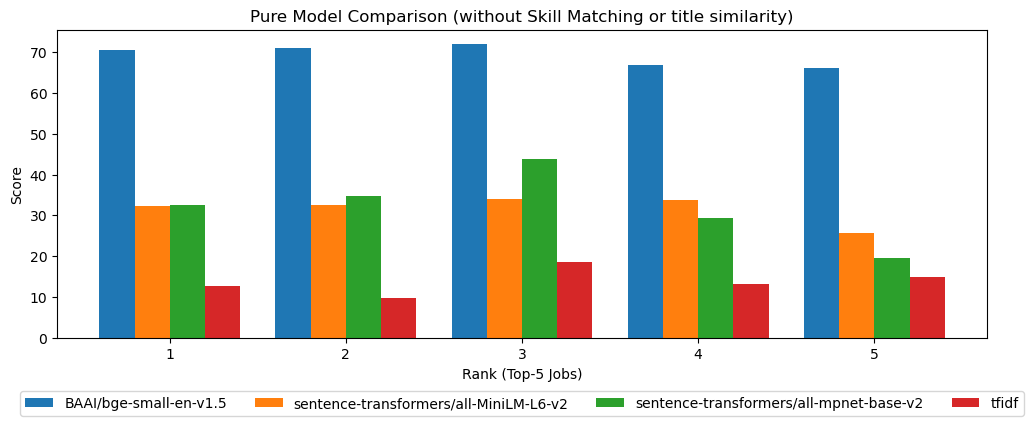

In [73]:
bar_width = 0.2
k = 5
ranks = np.arange(1, k+1)
plt.figure(figsize=(12,4))

for i, (model, scores) in enumerate(model_scores.items()):
    offset = ranks + i * bar_width
    plt.bar(offset, scores, width=bar_width, label=model)

plt.xlabel("Rank (Top-5 Jobs)")
plt.ylabel("Score")
plt.title("Pure Model Comparison (without Skill Matching or title similarity)")

plt.xticks(ranks + bar_width*1.5, ranks)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.show()

In [82]:
methods = ["BAAI/bge-small-en-v1.5", "sentence-transformers/all-MiniLM-L6-v2", "sentence-transformers/all-mpnet-base-v2", "tfidf"]
model_scores = {}
for method in methods:

    pairs, topk = compute_fused_pairs_and_topk(
        resume_df=resume_out,
        job_df=job_out.loc[[99, 154, 396, 511, 644]],
        top_k=5,
        model_name=method,
        skill_weight=skill_weight,
        model_weight=model_weight,
        title_weight=title_weight,
    )
    
    model_scores[method] = pairs["final_score"].values



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20777.32it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12047.89it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11842.10it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.positi

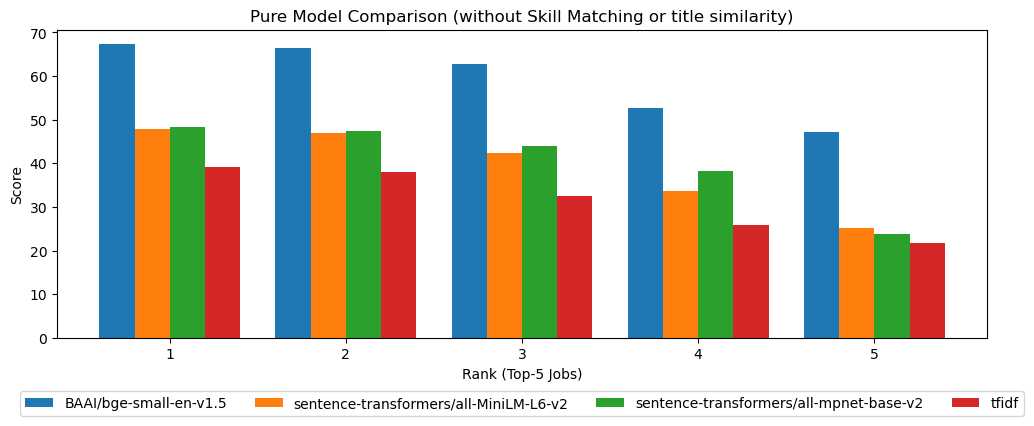

In [83]:
bar_width = 0.2
k = 5
ranks = np.arange(1, k+1)
plt.figure(figsize=(12,4))

for i, (model, scores) in enumerate(model_scores.items()):
    offset = ranks + i * bar_width
    plt.bar(offset, scores, width=bar_width, label=model)

plt.xlabel("Rank (Top-5 Jobs)")
plt.ylabel("Score")
plt.title("Pure Model Comparison (without Skill Matching or title similarity)")

plt.xticks(ranks + bar_width*1.5, ranks)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.show()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18644.27it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


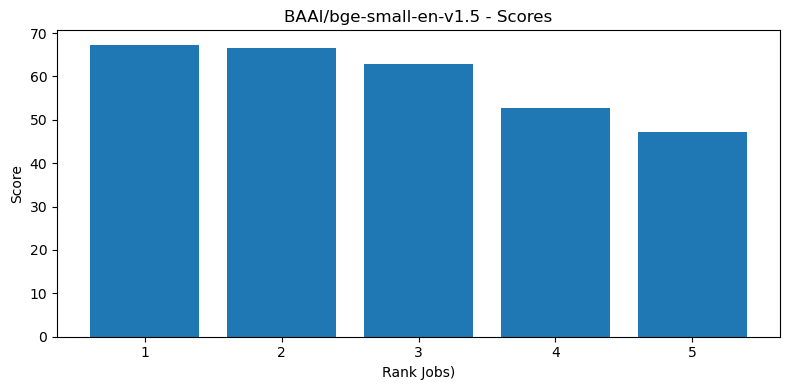

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9270.47it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


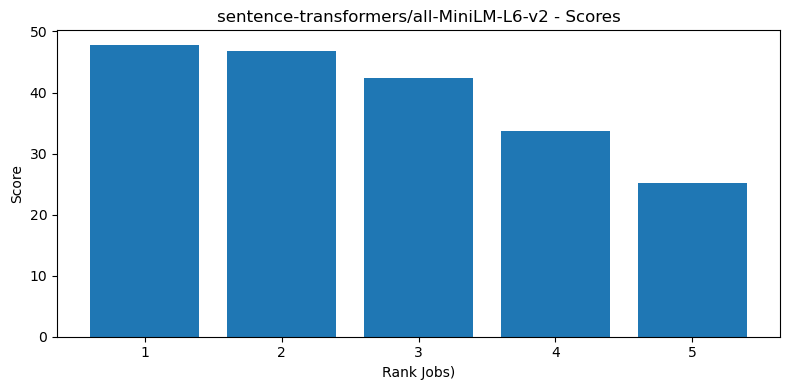

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4359.46it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


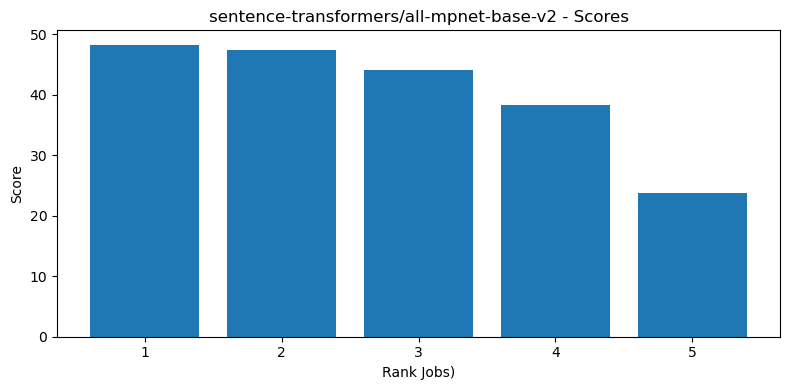

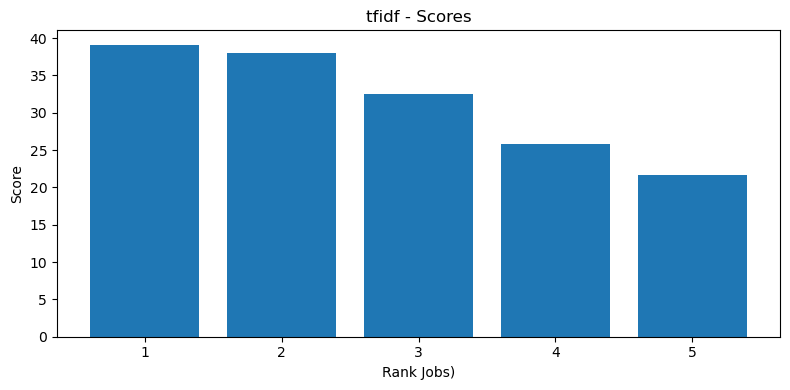

In [81]:
methods = [
    "BAAI/bge-small-en-v1.5",
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "tfidf"
]

k = 5
ranks = np.arange(1, k+1)

for method in methods:

    pairs, topk = compute_fused_pairs_and_topk(
        resume_df=resume_out,
        job_df=job_out.loc[[99, 154, 396, 511, 644]],
        top_k=5,
        model_name=method,
        skill_weight=skill_weight,
        model_weight=model_weight,
        title_weight=title_weight,
    )

    scores = topk.sort_values("rank")["final_score"].values

    plt.figure(figsize=(8,4))

    plt.bar(ranks, scores)

    plt.xlabel("Rank Jobs)")
    plt.ylabel("Score")
    plt.title(f"{method} - Scores")

    plt.xticks(ranks)

    plt.tight_layout()
    plt.show()